In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as ticker
from tqdm import tqdm
import seaborn as sns

plt.rc('font', size = 12)
plt.rc('xtick', labelsize = 11)
plt.rc('ytick', labelsize = 11)
plt.rc('legend', fontsize = 12)
plt.rc('axes', labelsize = 14)

aa = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y','-']
aa_id = {}
for id, a in enumerate(aa): aa_id[a]= id

WT="NITNLCPFGEVFNATRFASVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTNVYADSFVIRGDEVRQIAPGQTGKIADYNYKLPDDFTGCVIAWNSNNLDSKVGGNYNYLYRLFRKSNLKPFERDISTEIYQAGSTPCNGVEGFNCYFPLQSYGFQPTNGVGYQPYRVVVLSFELLHAPATVCGPKKST"
    
q = 20
L = 178

BEGIN = 18
END = 5

WT_SEQ = np.array([aa_id[char] for char in WT])
WT_SEQ = WT_SEQ[BEGIN:-END]
WT_SEQ

array([15, 17, 19,  0, 18, 11, 14,  8, 14,  7, 15, 11,  1, 17,  0,  2, 19,
       15, 17,  9, 19, 11, 15,  0, 15,  4, 15, 16,  4,  8,  1, 19,  5, 17,
       15, 12, 16,  8,  9, 11,  2,  9,  1,  4, 16, 11, 17, 19,  0,  2, 15,
        4, 17,  7, 14,  5,  2,  3, 17, 14, 13,  7,  0, 12,  5, 13, 16,  5,
        8,  7,  0,  2, 19, 11, 19,  8,  9, 12,  2,  2,  4, 16,  5,  1, 17,
        7,  0, 18, 11, 15, 11, 11,  9,  2, 15,  8, 17,  5,  5, 11, 19, 11,
       19,  9, 19, 14,  9,  4, 14,  8, 15, 11,  9,  8, 12,  4,  3, 14,  2,
        7, 15, 16,  3,  7, 19, 13,  0,  5, 15, 16, 12,  1, 11,  5, 17,  3,
        5,  4, 11,  1, 19,  4, 12,  9, 13, 15, 19,  5,  4, 13, 12, 16, 11,
        5, 17,  5, 19, 13, 12, 19, 14, 17, 17, 17,  9, 15,  4,  3,  9,  9,
        6,  0, 12,  0, 16, 17,  1,  5])

In [2]:
def train_test_split(delta, G, test_size = 0.5):
    Mtot, N = delta.shape
    idx = np.random.permutation(Mtot)      
    delta = delta[idx]
    G = G[idx]
    Mtest =  int(Mtot*test_size)
    delta_test = delta[:Mtest, :]
    delta_train = delta[Mtest:,:]
    G_test = G[:Mtest]
    G_train = G[Mtest:] 
    return delta_train, delta_test, G_train, G_test

In [3]:
def ridge_regression_stable(delta, G, lam):
    n, p = delta.shape

    delta_mean = np.mean(delta, axis=0)
    X = delta - delta_mean[None, :]

    G_mean = np.mean(G)
    y = G - G_mean

    # SVD of X (not X.T @ X) — avoids squaring the condition number
    U, s, Vt = np.linalg.svd(X, full_matrices=False)

    # Ridge solution: V @ diag(s / (s² + n*lam)) @ U.T @ y
    d = s / (s**2 + n * lam)
    g_hat = Vt.T @ (d * (U.T @ y))

    return g_hat, delta_mean, G_mean
def ridge_regression(delta, G, lam):

    n, p = delta.shape

    delta_mean = np.mean(delta, axis = 0)

    X = delta - delta_mean[None,:]

    G_mean = np.mean(G)

    y = G - G_mean
    
    g_hat = np.linalg.solve(X.T@X + n * lam * np.eye(p), X.T @ y)

    return g_hat, delta_mean, G_mean

In [4]:
exp_data_path = 'exp_data/'
q = 20
AB = 'S2X16'
with open(exp_data_path+"starr_nature/DMS_"+AB+".csv", 'r') as file:
    line = file.readline().split(sep = ',')
    M = int(line[0])
    N = int(line[1])
    print(M,N)

    delta = np.zeros((M,N),dtype = np.float64)
    G = np.zeros(M,dtype = np.float64)
    for m in range(M):
        line = file.readline().split(sep = ',')
        delta[m] = [int(line[i]) for i in range(N)]
        G[m] = float(line[-1])
        
# remove gap (and WT)
def get_cols_to_remove(L, q, WT):
    cols = set()
    for site in range(L):
        base = site * (q+1)
        cols.add(base + q )       # ultima feature del sito
        #cols.add(base + WT[site])     # feature wild-type del sito
    return sorted(cols)

cols_to_remove = get_cols_to_remove(L, q, WT_SEQ)
cols_to_keep   = [i for i in range(N) if i not in set(cols_to_remove)]

delta_new = delta[:, cols_to_keep]
print(f"Shape originale: {delta.shape}")
print(f"Colonne rimosse: {len(cols_to_remove)}")
print(f"Shape finale:    {delta_new.shape}") 
delta = delta_new.copy()

1672 3738
Shape originale: (1672, 3738)
Colonne rimosse: 178
Shape finale:    (1672, 3560)


In [27]:
n_trials = 30

split_fractions = [0.05,0.15,0.25,0.35,0.45,0.55,0.65,0.75,0.8,0.85,0.9,0.95,0.975]
mu_grid = 10**(np.array([-9,-8,-7,-6.5,-6,-5.5,-5,-4.5,-4,-3.5,-3,-2,-1,0]))
r_values = np.zeros(len(split_fractions))
risk_values = np.zeros((len(split_fractions), len(mu_grid), n_trials))

from tqdm import tqdm

for i, test_size in enumerate(split_fractions):

    print(i)

    for j, mu in enumerate(mu_grid):

        for trial in tqdm(range(n_trials)):

            delta_train, delta_test, G_train, G_test = train_test_split(delta, G, test_size=test_size)

            if j == 0 and trial == 0: r_values[i] = q * L / len(G_train)

            if mu < 5*10**(-8): g_hat, delta_mean, G_mean  = ridge_regression_stable(delta_train, G_train, mu)
            else: g_hat, delta_mean, G_mean  = ridge_regression(delta_train, G_train, mu)
            X_test = delta_test - delta_mean[None,:]
            G_pred = X_test @ g_hat + G_mean
            risk_values[i,j,trial] = np.mean((G_pred-G_test)**2)
        print(np.mean(risk_values[i,j,:]))

avg_risk = np.mean(risk_values  , axis = 2)
std_risk = np.std(risk_values, axis = 2)/np.sqrt(n_trials)      

0


100%|██████████| 30/30 [01:07<00:00,  2.25s/it]


0.44308783094079623


100%|██████████| 30/30 [01:14<00:00,  2.48s/it]


0.4217594430550118


...

1.5425295769554523


100%|██████████| 30/30 [00:16<00:00,  1.83it/s]


1.6712548282746087


100%|██████████| 30/30 [00:16<00:00,  1.86it/s]

1.7798853743979461


In [28]:
data = pd.DataFrame({'Ab': [],'q':[], 'L': [], 'M': [], 'r': [], 'mu': [], 'R': [], 'sR': [],'nTest': [],'nTrial': []}) 

In [29]:
for j, mu in enumerate(mu_grid):
    for i, r in enumerate(r_values):
        data = pd.concat([data, pd.DataFrame({'Ab': [AB],'q':[q], 'L': [L], 'M': [int(q*L/r)], 'r': [r], 'mu': [mu], 'R': [avg_risk[i,j]], 'sR': [std_risk[i,j]],'nTest': [int(split_fractions[i]*len(G))],'nTrial': [n_trials]})])

In [30]:
outfile = "exp_data/test_risk/"+AB+".csv"
data.to_csv(outfile, index = False)

In [145]:
outfile = "exp_data/test_risk/"+AB+".csv"
data = pd.read_csv(outfile)
data

,Ab,q,L,M,r,mu,R,sR,nTest,nTrial
0,S2X16,20.0,178.0,1589.0,2.240403,1.000000e-09,0.443088,0.045117,83.0,30.0
1,S2X16,20.0,178.0,1422.0,2.503516,1.000000e-09,0.375417,0.019235,250.0,30.0
2,S2X16,20.0,178.0,1254.0,2.838915,1.000000e-09,0.415717,0.016608,418.0,30.0
3,S2X16,20.0,178.0,1087.0,3.275069,1.000000e-09,0.425967,0.010249,585.0,30.0
4,S2X16,20.0,178.0,920.0,3.869565,1.000000e-09,0.427460,0.008156,752.0,30.0
...,...,...,...,...,...,...,...,...,...,...
177,S2X16,20.0,178.0,335.0,10.626866,1.000000e+00,1.737592,0.011932,1337.0,30.0
178,S2X16,20.0,178.0,251.0,14.183267,1.000000e+00,1.726687,0.010314,1421.0,30.0
179,S2X16,20.0,178.0,168.0,21.190476,1.000000e+00,1.747672,0.008137,1504.0,30.0
180,S2X16,20.0,178.0,84.0,42.380952,1.000000e+00,1.766016,0.009561,1588.0,30.0


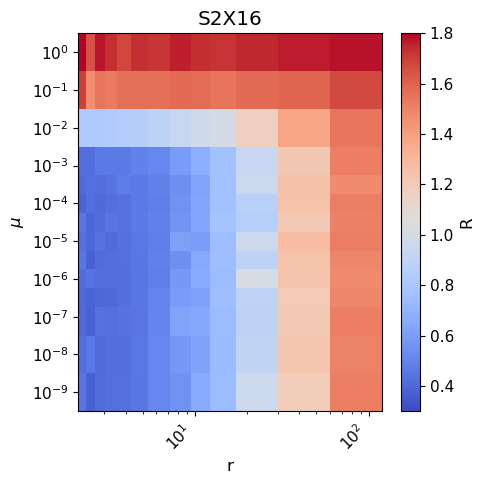

In [6]:


fig, ax = plt.subplots(1, 1)
fig.set_figheight(5)
fig.set_figwidth(5)

AB = "S2X16"
temp = data[(data['Ab'] == AB)]

pivot = temp.pivot(index='mu', columns='r', values='R')
densities = pivot.columns.values  # mu
temps = pivot.index.values        # r
Z = pivot.values

# Edges in log space
log_d = np.log10(densities)
x_edges = 10**np.concatenate((
    [log_d[0] - (log_d[1] - log_d[0]) / 2],
    (log_d[:-1] + log_d[1:]) / 2,
    [log_d[-1] + (log_d[-1] - log_d[-2]) / 2]
))

log_t = np.log10(temps)
y_edges = 10**np.concatenate((
    [log_t[0] - (log_t[1] - log_t[0]) / 2],
    (log_t[:-1] + log_t[1:]) / 2,
    [log_t[-1] + (log_t[-1] - log_t[-2]) / 2]
))

im = ax.pcolormesh(x_edges, y_edges, Z, cmap='coolwarm',
                   shading='auto', vmin=0.3, vmax=1.8)

ax.set_xscale('log')
ax.set_yscale('log')

# Let matplotlib pick clean log ticks automatically
ax.xaxis.set_major_locator(ticker.LogLocator(base=10, numticks=10))
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())
ax.yaxis.set_major_locator(ticker.LogLocator(base=10, numticks=12))
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())

# Remove minor ticks clutter
#ax.xaxis.set_minor_locator(ticker.NullLocator())
#ax.yaxis.set_minor_locator(ticker.NullLocator())

plt.xticks(rotation=45, ha='right')

plt.colorbar(im, ax=ax, label='R')
ax.set_title(AB)
ax.set_xlabel('r')
ax.set_ylabel('$\\mu$')

plt.tight_layout()
plt.show()

In [7]:
mu_opt = []
smu_opt = []
mu_max = []
mu_min = []
R_opt = []
r_values = []

for id, temp in data.groupby("r"):

    id_opt = np.argmin(temp['R'].values)
    row_opt = temp.iloc[id_opt] 
    R_opt_temp = row_opt['R']
    sR_opt_temp = row_opt['sR']
    mus = []
    for row_id, row in temp.iterrows(): 
        if row['R'] - R_opt_temp < np.sqrt(sR_opt_temp**2+row['sR']**2): mus.append(row['mu'])

    mu_opt.append(row_opt['mu'])
    smu_opt.append(np.std(mus))
    mu_min.append(np.min(mus)) 
    mu_max.append(np.max(mus)) 
    R_opt.append(row_opt['R'])
    r_values.append(row_opt['r'])

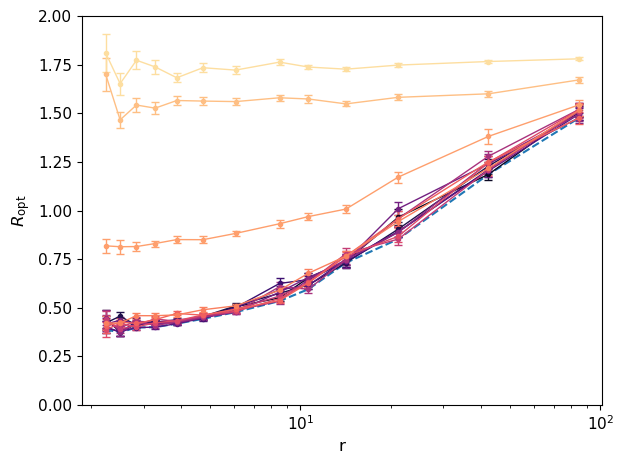

In [8]:
colors = sns.color_palette("magma", len(data['mu'].unique()))
i = -1
for id, temp in data.sort_values(by = 'mu').groupby("mu"):
    i += 1
    temp.sort_values(by = 'r', inplace=True)
    plt.errorbar(temp['r'], temp['R'], yerr = temp['sR'], marker = "o", capsize  =  3, markersize = 3, linewidth = 1, elinewidth=1,label = f"$\\mu = {id}$", c = colors[i])

plt.plot(r_values, R_opt, linestyle = '--')
plt.ylim(0,2)
plt.xscale("log")
plt.xlabel("r")
plt.ylabel('$R_{\\text{opt}}$')
plt.tight_layout()
plt.show()

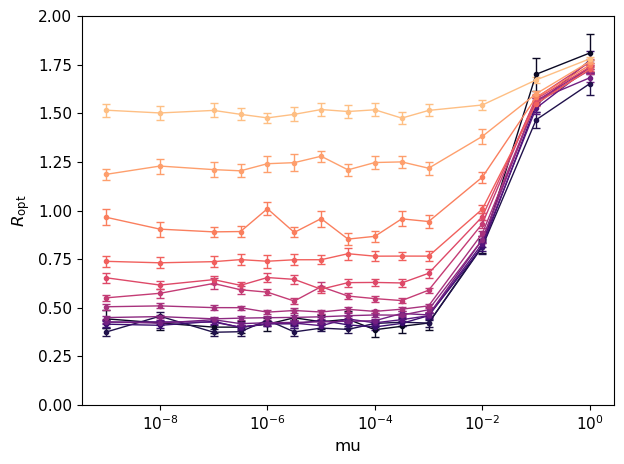

In [9]:
colors = sns.color_palette("magma", len(data['mu'].unique()))
i = -1
for id, temp in data.sort_values(by = 'r').groupby("r"):
    i += 1
    temp.sort_values(by = 'mu', inplace=True)
    plt.errorbar(temp['mu'], temp['R'], yerr = temp['sR'], marker = "o", capsize  =  3, markersize = 3, linewidth = 1, elinewidth=1,label = f"$\\mu = {id}$", c = colors[i])

plt.ylim(0,2)
plt.xscale("log")
plt.xlabel("mu")
plt.ylabel('$R_{\\text{opt}}$')
plt.tight_layout()
plt.show()

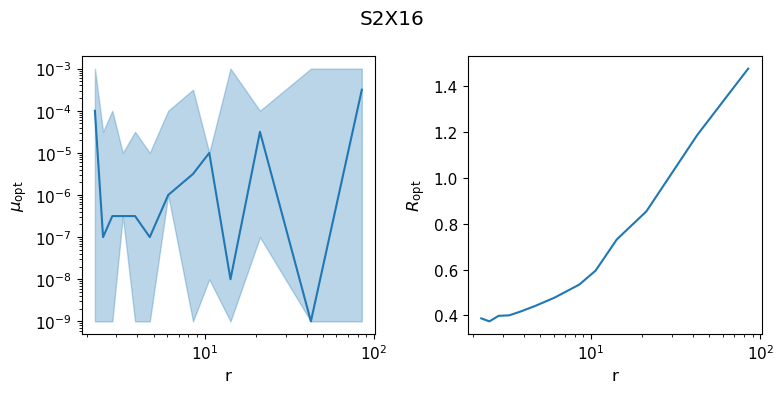

In [38]:
fig, [ax1, ax2] = plt.subplots(1,2) 
fig.set_figheight(4)
fig.set_figwidth(8)

fig.suptitle(AB)

#ax1.errorbar(r_values, mu_opt, smu_opt)
ax1.plot(r_values, mu_opt)
ax1.fill_between(r_values, mu_min, mu_max, alpha = 0.3, color = 'C0')

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("r")
ax1.set_ylabel('$\\mu_{\\text{opt}}$')

"""colors = sns.color_palette("magma", len(mu_grid))
i = -1
for id, temp in data.groupby("mu"):
    i += 1
    ax2.errorbar(temp['r'], temp['R'], yerr = temp['sR'], marker = "o", capsize  =  3, markersize = 3, linewidth = 1, elinewidth=1,label = f"$\\mu = {id}$", c = colors[i])"""

ax2.plot(r_values, R_opt)
ax2.set_xscale("log")
ax2.set_xlabel("r")
ax2.set_ylabel('$R_{\\text{opt}}$')

plt.tight_layout()
plt.show()

In [147]:
mu_values = []
Rmin_values = [] 

for id, temp in data.sort_values(by = 'mu').groupby("mu"):
    temp = temp[temp['r']<5]
    Rmin = np.sum(temp['R']*temp['sR']**2)/np.sum(temp['sR']**2)
    mu_values.append(id)
    Rmin_values.append(Rmin)

0.2253536533040482


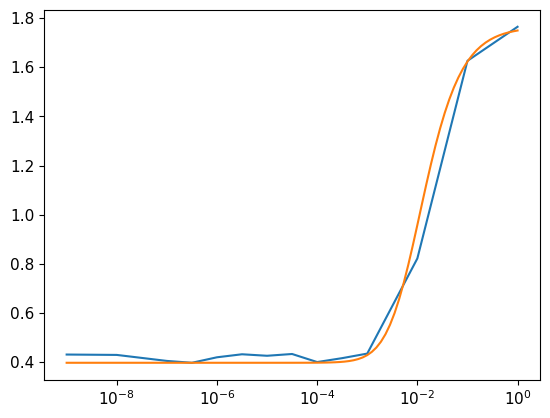

In [148]:
mu_values = np.array(mu_values)
Rmin_values = np.array(Rmin_values)

plt.plot(mu_values, Rmin_values)

R0 = np.min(Rmin_values)
SNR = Rmin_values[-1]*(1+(L*mu_values[-1])**2)/(L*mu_values[-1])**2-R0 
Fmis = R0/(R0+SNR)
print(Fmis)

mus = np.geomspace(10**(-9),1,100)
plt.plot(mus,R0+SNR*(L*mus)**2/((1+L*mus)**2))
plt.xscale("log")

## Piccolo check

In [137]:
exp_data_path = 'exp_data/'
q = 20
with open(exp_data_path+"starr_nature/DMS_"+AB+".csv", 'r') as file:
    line = file.readline().split(sep = ',')
    M = int(line[0])
    N = int(line[1])

    delta = np.zeros((M,N),dtype = np.float32)
    G = np.zeros(M,dtype = np.float64)
    for m in range(M):
        line = file.readline().split(sep = ',')
        delta[m] = [int(line[i]) for i in range(N)]
        G[m] = float(line[-1])
    # remove gap       
    cols_to_remove = get_cols_to_remove(L, q, WT_SEQ)
    cols_to_keep   = [i for i in range(N) if i not in set(cols_to_remove)]

    delta_new = delta[:, cols_to_keep]
    delta = delta_new.copy()    

In [279]:
g, delta_mean, G_mean = ridge_regression(delta, G, 10**(-4)) 


In [280]:
g

array([ 0.        ,  0.        ,  0.        , ..., -0.03249184,
        0.        ,  0.        ], shape=(3560,))

In [281]:
g_matrix = g.reshape((len(g)//q, q)) 

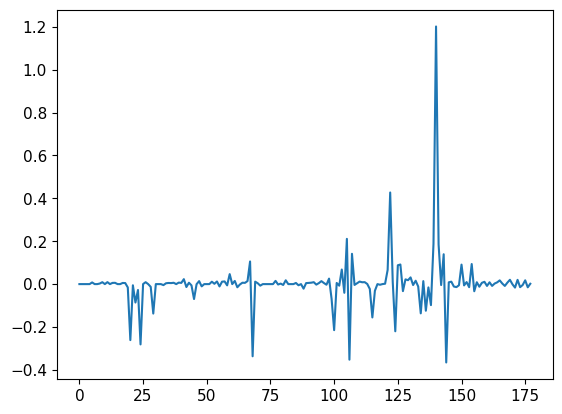

In [285]:
plt.plot(np.mean(g_matrix, axis = 1))

In [274]:
L,q = g_matrix.shape
for site in range(L):
    g_matrix[site,:] -= (np.sum(g_matrix[site,:])-g_matrix[site, WT_SEQ[site]])/(q-1)

In [275]:
norm = np.sum(g_matrix**2)
print(norm)
F = np.sum([g_matrix[site,WT_SEQ[site]]**2 for site in range(L)])/norm
print(F)

932.1161268882338
0.08268488310361792


In [287]:
norms = []
Fs = []
for mu in mu_grid:
    print(mu) 
    g, delta_mean, G_mean = ridge_regression(delta, G, mu) 
    g_matrix = g.reshape((len(g)//q, q)) 
    L,q = g_matrix.shape
    for site in range(L):
        g_matrix[site,:] -= (np.sum(g_matrix[site,:])-g_matrix[site, WT_SEQ[site]])/(q-1)
    norm = np.sum(g_matrix**2)
    F = np.sum([g_matrix[site,WT_SEQ[site]]**2 for site in range(L)])/norm
    norms.append(norm)
    Fs.append(F)

1e-07
1e-06
1e-05
0.0001
0.001
0.01
0.1


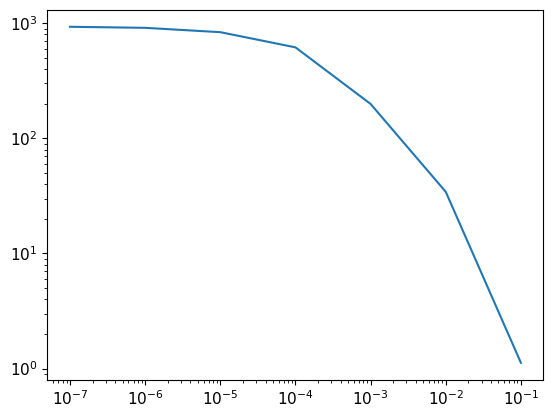

In [290]:
plt.plot(mu_grid, norms)
plt.xscale("log")
plt.yscale("log")

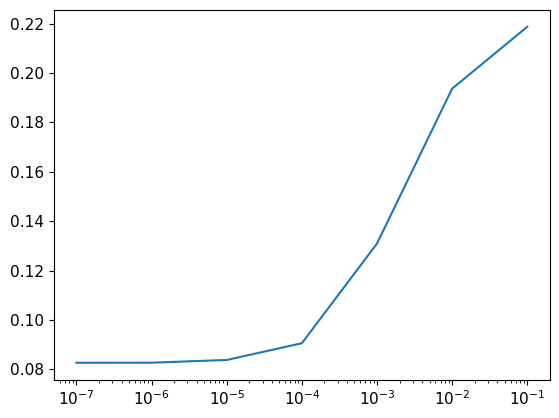

In [291]:
plt.plot(mu_grid, Fs)
plt.xscale("log")

## SNR

In [11]:
def optimal_regularization(data):
    mu_opt = []
    mu_max = []
    mu_min = []
    R_opt = []
    r_values = []

    for id, temp in data.sort_values(by = 'r').groupby("r"):

        id_opt = np.argmin(temp['R'].values)
        row_opt = temp.iloc[id_opt] 
        R_opt_temp = row_opt['R']
        sR_opt_temp = row_opt['sR']
        mus = []
        for row_id, row in temp.iterrows(): 
            if row['R'] - R_opt_temp < np.sqrt(sR_opt_temp**2+row['sR']**2): mus.append(row['mu'])

        mu_opt.append(row_opt['mu'])
        mu_min.append(np.min(mus)) 
        mu_max.append(np.max(mus)) 
        R_opt.append(row_opt['R'])
        r_values.append(row_opt['r'])
    return mu_opt, mu_min, mu_max, R_opt, r_values    

def misspecified_fraction(data):

    mu_values = []
    Rmin_values = [] 

    for id, temp in data.sort_values(by = 'mu').groupby("mu"):
        temp = temp[temp['r']<5]
        Rmin = np.sum(temp['R']*temp['sR']**2)/np.sum(temp['sR']**2)
        mu_values.append(id)
        Rmin_values.append(Rmin)  

    mu_values = np.array(mu_values)
    Rmin_values = np.array(Rmin_values)

    plt.plot(mu_values, Rmin_values)

    R0 = np.min(Rmin_values)
    SNR = np.max(Rmin_values)*(1+(L*mu_values[-1])**2)/(L*mu_values[-1])**2-R0 
    Fmis = R0/(R0+SNR)

    mus = np.geomspace(10**(-9),1,100)
    plt.plot(mus,R0+SNR*(L*mus)**2/(1+(L*mus)**2))
    plt.xscale("log")     
    return Fmis, R0, SNR  

In [149]:
mu = 10**(-5)

g, delta_mean, G_mean = ridge_regression(delta, G, mu) 

g_matrix = g.reshape((len(g)//q, q)) 
for site in range(L): g_matrix[site,:] -= (np.sum(g_matrix[site,:])-g_matrix[site, WT_SEQ[site]])/(q-1) 

norm = np.sum(g_matrix**2)
F = np.sum([g_matrix[site,WT_SEQ[site]]**2 for site in range(L)])/norm

In [150]:
SNR_from_g = norm/(q-1)/L * ((q-1)*(1.-1./L)*F+1-F)
SNR_from_g

np.float64(1.0341532942816702)

In [151]:
mu_values = []
Rmin_values = [] 
sRmin_values = []

for id, temp in data.sort_values(by = 'mu').groupby("mu"):
    temp = temp[temp['r']<5]
    Rmin = np.sum(temp['R']*temp['sR']**2)/np.sum(temp['sR']**2)
    sRmin = 1/np.sqrt(np.sum(temp['sR']**(-2)))
    mu_values.append(id)
    Rmin_values.append(Rmin)  
    sRmin_values.append(sRmin)


mu_values = np.array(mu_values)
Rmin_values = np.array(Rmin_values)
sRmin_values = np.array(sRmin_values)

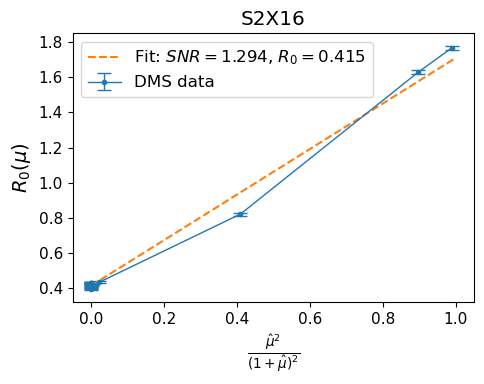

In [152]:
fig, ax = plt.subplots()
fig.set_figheight(4)
fig.set_figwidth(5)

ax.errorbar((L*mu_values)**2/((1+L*mu_values)**2), Rmin_values, yerr = sRmin_values, marker = "o", capsize  =  5, markersize = 3, linewidth = 1, elinewidth=1, label = 'DMS data')

SNR_base, R0_base = np.polyfit(x = (L*mu_values)**2/((1+L*mu_values)**2), y = Rmin_values, w = 1./sRmin_values, deg = 1)

ax.plot(np.linspace(0,1), np.linspace(0,1) * SNR_base + R0_base ,linestyle = '--', label = f'Fit: $SNR = {round(SNR_base, 3)}$, $R_0= {round(R0_base,3)}$')

ax.set_title(AB)
ax.set_xlabel("$\\frac{\hat{\\mu}^2}{(1+\hat{\\mu})^2} $")
ax.set_ylabel("$R_0(\\mu)$")
ax.legend()

plt.tight_layout()
plt.show()

## Hiding sites to change Fmis

In [54]:
# let's take inferred g as ground truth
print(g)
print(q)
print(L)
print(f"The total norm of g in the zsm gauge is {norm}")

[-0.02255008 -0.02255008 -0.02255008 ... -0.00998406 -0.00998406
  0.0110934 ]
20
178
The total norm of g in the zsm gauge is 715.9855752512354


In [ ]:
# idea: mask some sites so that the misspecification ratio rises
p = 0.5
mask_sites = np.random.choice([0,1], p = [p,1-p],size = L) # for now random, but interesting things can be done here to check effect of sites 
L_new = np.sum(mask_sites) 
mask_matrix = mask_sites[:,None] + np.zeros((L,q), dtype = np.int32) 
mask = mask_matrix.flatten()

new_norm = np.sum(mask_matrix*g_matrix**2)

x = (norm-new_norm)/norm

print(f"New norm: {new_norm}, so I have hidden a fraction x = {x} of the parameter vector")

delta_masked = mask*delta

New norm: 315.22539047562935, so I have hidden a fraction x = 0.5597322049888805 of the parameter vector


In [ ]:
n_trials = 5

split_fractions = [0.1,0.3,0.5,0.7]
mu_grid = 10**(np.array([-5,-4.,-3,-2,-1,0]))
r_values = np.zeros(len(split_fractions))
risk_values = np.zeros((len(split_fractions), len(mu_grid), n_trials))

from tqdm import tqdm

for i, test_size in enumerate(split_fractions):

    print(i)

    for j, mu in enumerate(mu_grid):

        for trial in tqdm(range(n_trials)):

            delta_train, delta_test, G_train, G_test = train_test_split(delta_masked, G, test_size=test_size)

            if j == 0 and trial == 0: r_values[i] = q * L_new / len(G_train)

            if mu < 5*10**(-8): g_hat, delta_mean, G_mean  = ridge_regression_stable(delta_train, G_train, mu)
            else: g_hat, delta_mean, G_mean  = ridge_regression(delta_train, G_train, mu)
            X_test = delta_test - delta_mean[None,:]
            G_pred = X_test @ g_hat + G_mean
            risk_values[i,j,trial] = np.mean((G_pred-G_test)**2)
        print(np.mean(risk_values[i,j,:]))

avg_risk = np.mean(risk_values  , axis = 2)
std_risk = np.std(risk_values, axis = 2)/np.sqrt(n_trials)      

0


100%|██████████| 5/5 [00:07<00:00,  1.57s/it]


0.8812882308183438


100%|██████████| 5/5 [00:07<00:00,  1.49s/it]


0.875732251207592


...

1.2419688123570722


100%|██████████| 5/5 [00:07<00:00,  1.58s/it]


1.5886233014149096


100%|██████████| 5/5 [00:06<00:00,  1.32s/it]

1.749812948195192


In [86]:
data = pd.DataFrame({'Ab': [],'q':[], 'L': [], 'M': [], 'r': [], 'mu': [], 'R': [], 'sR': [],'nTest': [],'nTrial': []}) 

In [87]:
for j, mu in enumerate(mu_grid):
    for i, r in enumerate(r_values):
        data = pd.concat([data, pd.DataFrame({'Ab': [AB],'q':[q], 'L': [L_new], 'M': [int(q*L_new/r)], 'r': [r], 'mu': [mu], 'R': [avg_risk[i,j]], 'sR': [std_risk[i,j]],'nTest': [int(split_fractions[i]*len(G))],'nTrial': [n_trials]})])

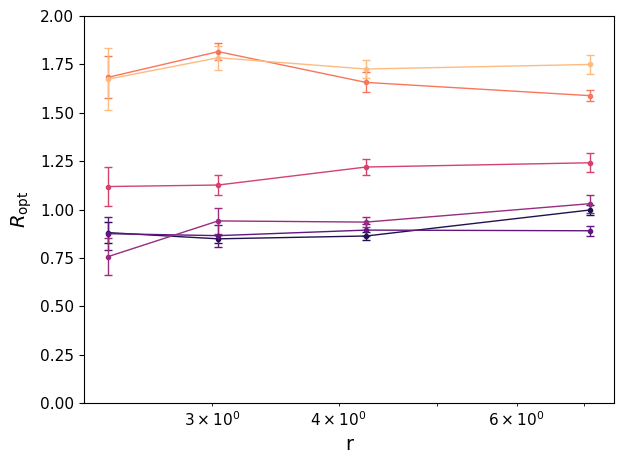

In [88]:
colors = sns.color_palette("magma", len(data['mu'].unique()))
i = -1
for id, temp in data.sort_values(by = 'mu').groupby("mu"):
    i += 1
    temp.sort_values(by = 'r', inplace=True)
    plt.errorbar(temp['r'], temp['R'], yerr = temp['sR'], marker = "o", capsize  =  3, markersize = 3, linewidth = 1, elinewidth=1,label = f"$\\mu = {id}$", c = colors[i])

#plt.plot(r_values, R_opt, linestyle = '--')
plt.ylim(0,2)
plt.xscale("log")
plt.xlabel("r")
plt.ylabel('$R_{\\text{opt}}$')
plt.tight_layout()
plt.show()

In [89]:
mu_values = []
Rmin_values = [] 
sRmin_values = []

for id, temp in data.sort_values(by = 'mu').groupby("mu"):
    temp = temp[temp['r']<5]
    Rmin = np.sum(temp['R']*temp['sR']**2)/np.sum(temp['sR']**2)
    sRmin = 1/np.sqrt(np.sum(temp['sR']**(-2)))
    mu_values.append(id)
    Rmin_values.append(Rmin)  
    sRmin_values.append(sRmin)


mu_values = np.array(mu_values)
Rmin_values = np.array(Rmin_values)
sRmin_values = np.array(sRmin_values)

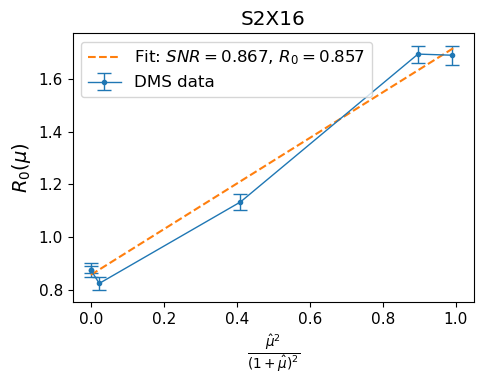

In [90]:
fig, ax = plt.subplots()
fig.set_figheight(4)
fig.set_figwidth(5)

ax.errorbar((L*mu_values)**2/((1+L*mu_values)**2), Rmin_values, yerr = sRmin_values, marker = "o", capsize  =  5, markersize = 3, linewidth = 1, elinewidth=1, label = 'DMS data')

SNR, R0 = np.polyfit(x = (L*mu_values)**2/((1+L*mu_values)**2), y = Rmin_values, w = 1./sRmin_values, deg = 1)

ax.plot(np.linspace(0,1), np.linspace(0,1) * SNR + R0 ,linestyle = '--', label = f'Fit: $SNR = {round(SNR, 3)}$, $R_0= {round(R0,3)}$')

ax.set_title(AB)
ax.set_xlabel("$\\frac{\hat{\\mu}^2}{(1+\hat{\\mu})^2} $")
ax.set_ylabel("$R_0(\\mu)$")
ax.legend()

plt.tight_layout()
plt.show()

In [111]:
risk_values.shape

(5, 3, 3, 5)

In [174]:
n_trials = 5

p_values = [0.05,0.15,0.25,0.35,0.45]#[0.1,0.2,0.3,0.4,0.5]

split_fractions = [0.1,0.2,0.3]
mu_grid = 10**(np.array([-4,-2.5,-1.5,-1]))
r_values = np.zeros(len(split_fractions))
x_values = np.zeros(len(p_values))
risk_values = np.zeros((len(p_values), len(split_fractions), len(mu_grid), n_trials))
avg_risk = np.zeros((len(p_values), len(split_fractions), len(mu_grid)))
std_risk = np.zeros((len(p_values), len(split_fractions), len(mu_grid)))

for id_x, p in enumerate(p_values):

    print(id_x) 

    mask_sites = np.random.choice([0,1], p = [p,1-p],size = L) # for now random, but interesting things can be done here to check effect of sites 
    L_new = np.sum(mask_sites) 
    mask_matrix = mask_sites[:,None] + np.zeros((L,q), dtype = np.int32) 
    mask = mask_matrix.flatten()

    new_norm = np.sum(mask_matrix*g_matrix**2)

    x = (norm-new_norm)/norm

    print(f"New norm: {new_norm}, so I have hidden a fraction x = {x} of the parameter vector")

    x_values[id_x] = x

    for i, test_size in enumerate(split_fractions):

        print(f"\t{i}")
        r_values[i] = q * L_new / len(G_train)

        for j, mu in enumerate(mu_grid):

            for trial in range(n_trials):

                delta_train, delta_test, G_train, G_test = train_test_split(delta, G, test_size=test_size)

                delta_train = mask*delta_train                

                if mu < 5*10**(-8): g_hat, delta_mean, G_mean  = ridge_regression_stable(delta_train, G_train, mu)
                else: g_hat, delta_mean, G_mean  = ridge_regression(delta_train, G_train, mu)
                X_test = delta_test - delta_mean[None,:]
                G_pred = X_test @ g_hat + G_mean
                risk_values[id_x, i,j,trial] = np.mean((G_pred-G_test)**2)
            print(np.mean(risk_values[id_x,i,j,:]))

avg_risk = np.mean(risk_values  , axis = 3)
std_risk = np.std(risk_values, axis = 3)/np.sqrt(n_trials)      

0
New norm: 545.3029935619151, so I have hidden a fraction x = 0.23838577900951324 of the parameter vector
	0
0.6196900361011838
0.7731464127934826
1.5495484866891012
1.8165976384411078
	1
0.6898041160639232
0.7419859178300904
1.421337816400213
1.5438404601544753
	2
0.7876152691863347
0.8397139738363162
1.3515134385120815
1.6076043430575453
1
New norm: 519.2431998496916, so I have hidden a fraction x = 0.2747829925250014 of the parameter vector
	0
0.6647553380347465
0.7992589355554751
1.3153180979083028
1.3913163579150318
	1
0.7421283499657939
0.8079448963110808
1.3733751654419906
1.4246854460400036
	2
0.6873862375939634
0.8059417089244973
1.264618408800842
1.6876895260642466
2
New norm: 584.7867256437489, so I have hidden a fraction x = 0.1832396085201913 of the parameter vector
	0
0.810425502427546
0.9440090000329265
1.452060049092768
1.517447699095786
	1
0.887856934405036
0.959356434567491
1.1607576293102804
1.4734621080836259
	2
0.7883732144442858
0.8357240340608938
1.3444296711896

In [115]:
data = pd.DataFrame({'Ab': [],'q':[], 'L': [], 'M': [], 'r': [],'x':[], 'mu': [], 'R': [], 'sR': [],'nTest': [],'nTrial': []}) 

In [175]:
for id_x, x in enumerate(x_values):     
    for j, mu in enumerate(mu_grid):
        for i, r in enumerate(r_values):
            data = pd.concat([data, pd.DataFrame({'Ab': [AB],'q':[q], 'L': [L], 'M': [int(q*L/r)], 'r': [r],'x':[x] ,'mu': [mu], 'R': [avg_risk[id_x,i,j]], 'sR': [std_risk[id_x,i,j]],'nTest': [int(split_fractions[i]*len(G))],'nTrial': [n_trials]})])

In [176]:
data.to_csv("exp_data/starr_nature/misspecification_"+AB+".csv", index = False)

In [153]:
data = pd.read_csv("exp_data/starr_nature/misspecification_"+AB+".csv")
data.columns

Index(['Ab', 'q', 'L', 'M', 'r', 'x', 'mu', 'R', 'sR', 'nTest', 'nTrial'], dtype='object')

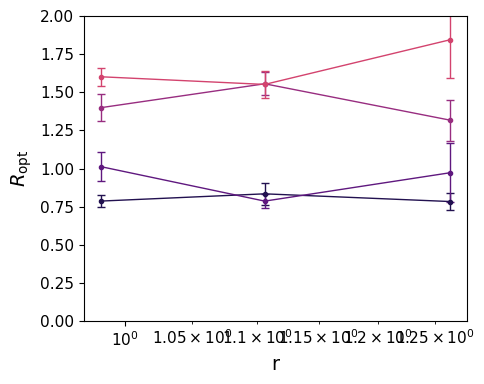

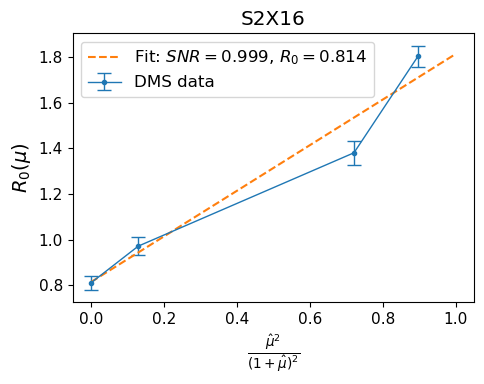

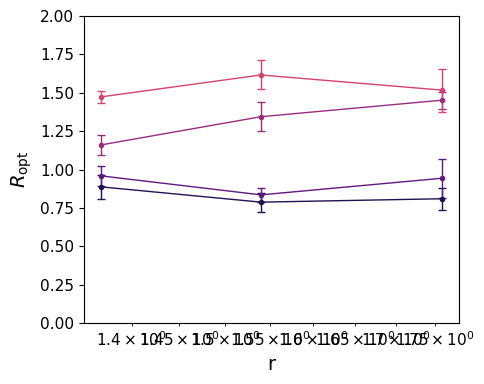

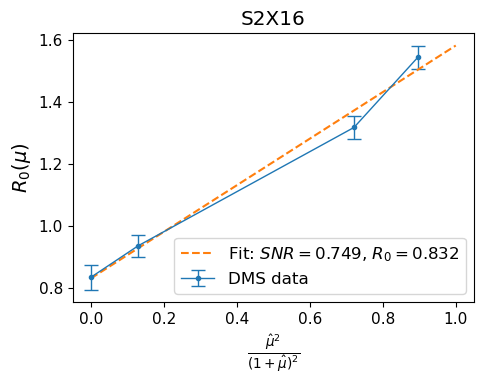

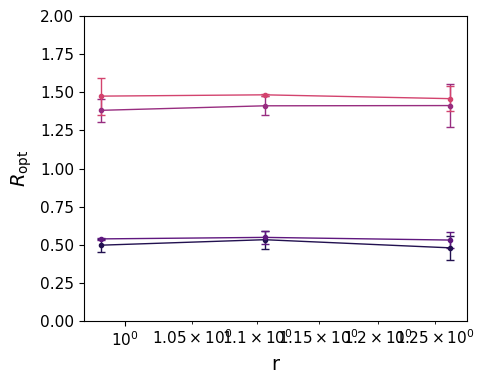

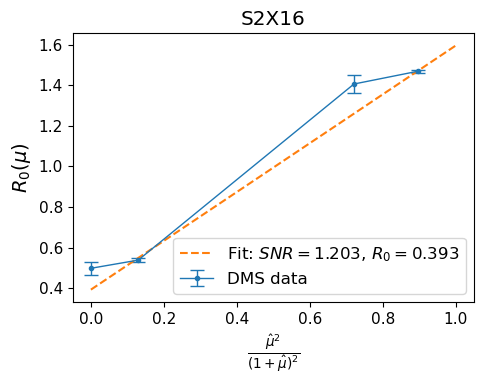

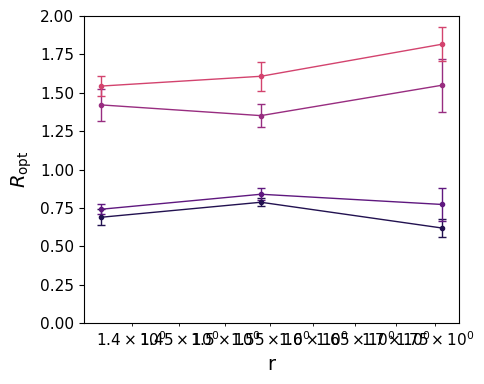

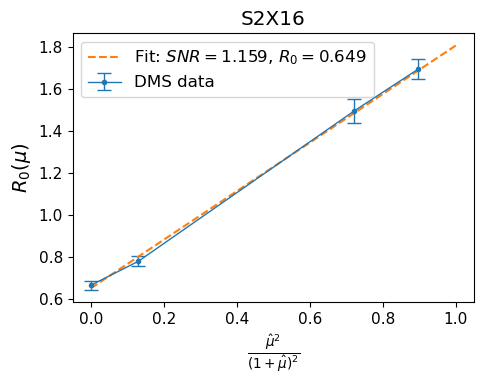

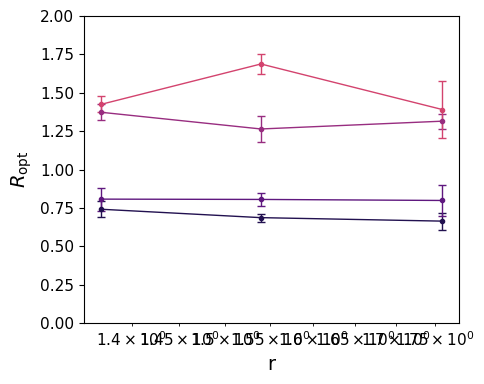

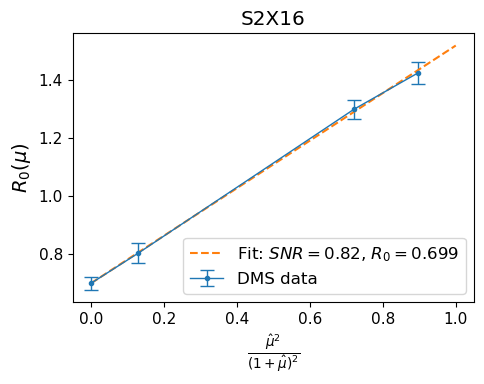

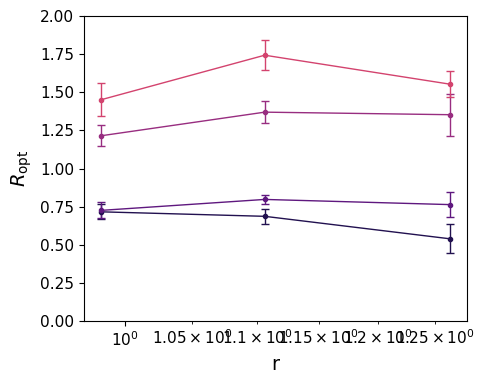

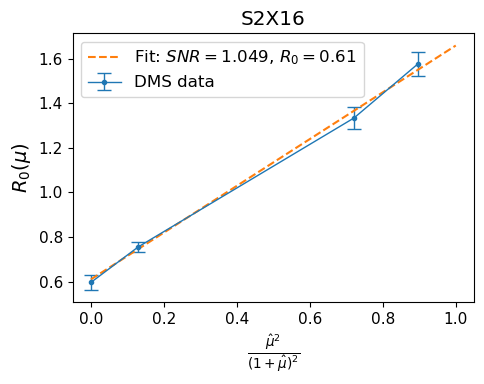

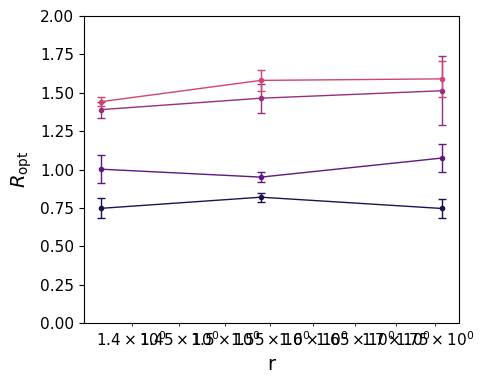

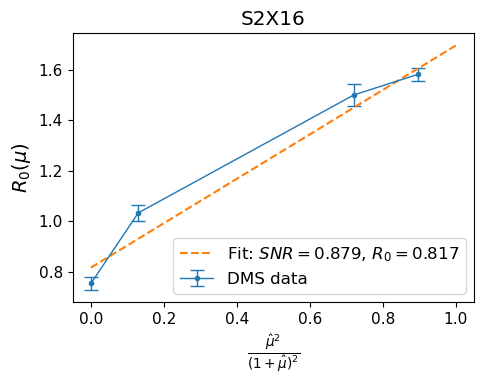

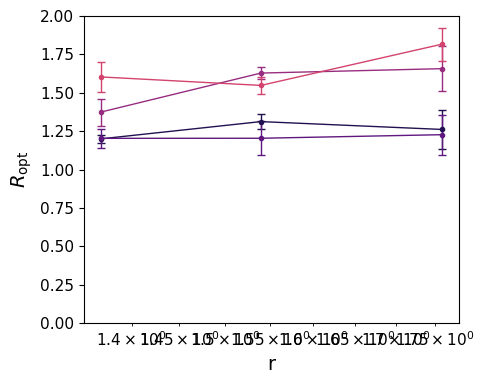

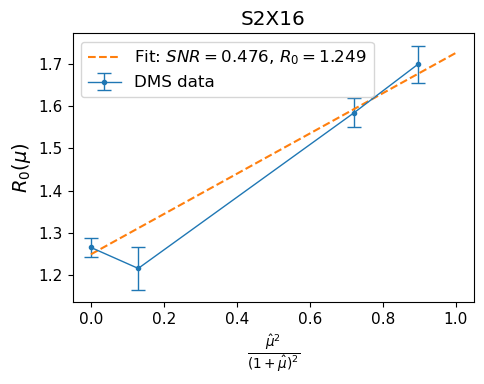

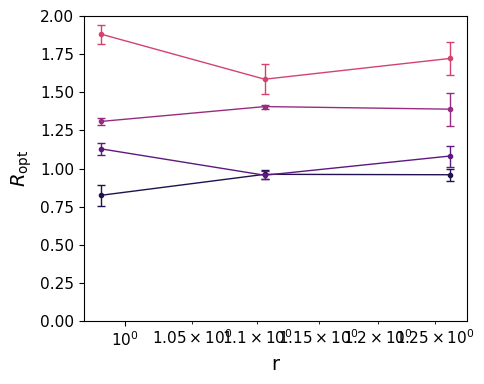

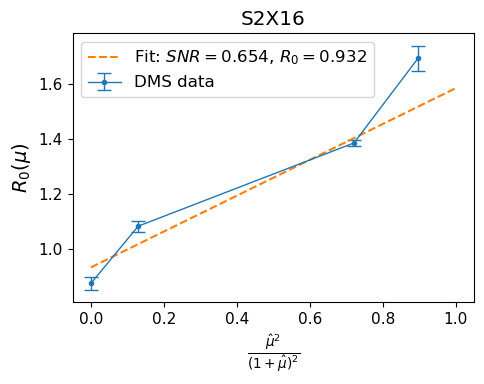

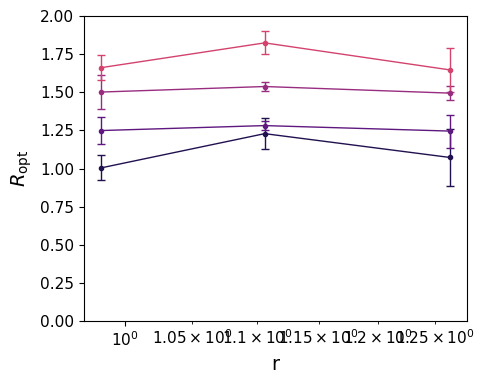

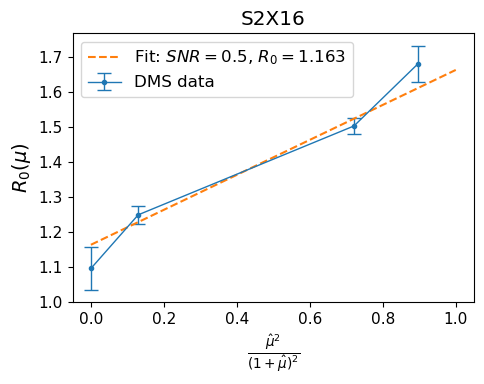

In [183]:
abs_results = pd.DataFrame({'Ab':[], 'x':[],'SNR':[],'R0':[],'sSNR':[],'sR0':[]})

for x, df in data.groupby('x'):

    plot = True
    if plot: 
        plt.figure(figsize = (5,4))
        colors = sns.color_palette("magma", len(data['mu'].unique()))
        i = -1
        for id, temp in df.sort_values(by = 'mu').groupby("mu"):
            i += 1
            temp.sort_values(by = 'r', inplace=True)
            plt.errorbar(temp['r'], temp['R'], yerr = temp['sR'], marker = "o", capsize  =  3, markersize = 3, linewidth = 1, elinewidth=1,label = f"$\\mu = {id}$", c = colors[i])

        plt.ylim(0,2)
        plt.xscale("log")
        plt.xlabel("r")
        plt.ylabel('$R_{\\text{opt}}$')
        plt.tight_layout()
        plt.show()

    mu_values = []
    Rmin_values = [] 
    sRmin_values = []

    for id, temp in df.sort_values(by = 'mu').groupby("mu"):
        temp = temp[temp['r']<5]
        Rmin = np.sum(temp['R']*temp['sR']**2)/np.sum(temp['sR']**2)
        sRmin = 1/np.sqrt(np.sum(temp['sR']**(-2)))
        mu_values.append(id)
        Rmin_values.append(Rmin)  
        sRmin_values.append(sRmin)


    mu_values = np.array(mu_values)
    Rmin_values = np.array(Rmin_values)
    sRmin_values = np.array(sRmin_values)

    par, cov = np.polyfit(x = (L*mu_values)**2/((1+L*mu_values)**2), y = Rmin_values, w = 1./sRmin_values, deg = 1, cov = True)
    SNR, R0 = par
    sSNR = cov[0,0]
    sR0 = cov[1,1]

    abs_results = pd.concat([abs_results, pd.DataFrame({'Ab':[AB], 'x':[x],'SNR':[SNR],'R0':[R0],'sSNR':[sSNR],'sR0':[sR0]})])

    plot = True
    if plot:
        fig, ax = plt.subplots()
        fig.set_figheight(4)
        fig.set_figwidth(5)

        ax.errorbar((L*mu_values)**2/((1+L*mu_values)**2), Rmin_values, yerr = sRmin_values, marker = "o", capsize  =  5, markersize = 3, linewidth = 1, elinewidth=1, label = 'DMS data')

        ax.plot(np.linspace(0,1), np.linspace(0,1) * SNR + R0 ,linestyle = '--', label = f'Fit: $SNR = {round(SNR, 3)}$, $R_0= {round(R0,3)}$')

        ax.set_title(AB)
        ax.set_xlabel("$\\frac{\hat{\\mu}^2}{(1+\hat{\\mu})^2} $")
        ax.set_ylabel("$R_0(\\mu)$")
        ax.legend()

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_62494/3842267232.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


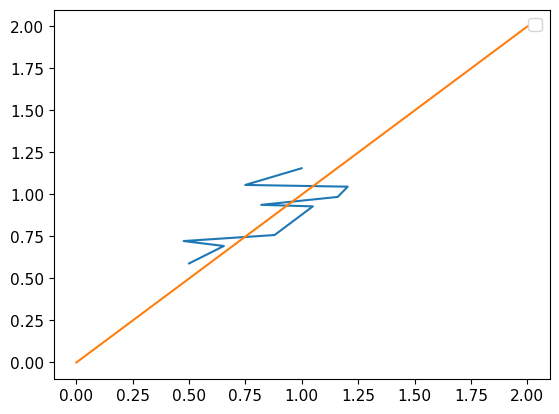

In [204]:
plt.plot(abs_results['SNR'], (1-abs_results['x'])*SNR_base)

plt.plot(np.linspace(0,2), np.linspace(0,2))
plt.legend()


In [185]:
abs_results

,Ab,x,SNR,R0,sSNR,sR0
0,S2X16,0.106406,0.998948,0.813855,0.018793,0.004095
0,S2X16,0.183240,0.748989,0.832319,0.004113,0.001405
0,S2X16,0.191201,1.203372,0.392794,0.002341,0.001100
0,S2X16,0.238386,1.159137,0.649279,0.001719,0.000198
0,S2X16,0.274783,0.819946,0.698507,0.000113,0.000026
0,S2X16,0.281842,1.048761,0.609832,0.001622,0.000238
0,S2X16,0.413719,0.878937,0.817497,0.012817,0.004128
0,S2X16,0.441406,0.475929,1.249221,0.004146,0.000928
0,S2X16,0.464086,0.654123,0.931653,0.013503,0.004724
0,S2X16,0.544307,0.499747,1.162656,0.005413,0.001749


/tmp/ipykernel_62494/2146231635.py:7: RuntimeWarning: divide by zero encountered in divide
  plt.plot(xs,sigma**2+(Fmis+(1-Fmis)*xs)/(1-Fmis-(1-Fmis)*xs)*(1-xs)*SNR_base)
/tmp/ipykernel_62494/2146231635.py:7: RuntimeWarning: invalid value encountered in multiply
  plt.plot(xs,sigma**2+(Fmis+(1-Fmis)*xs)/(1-Fmis-(1-Fmis)*xs)*(1-xs)*SNR_base)


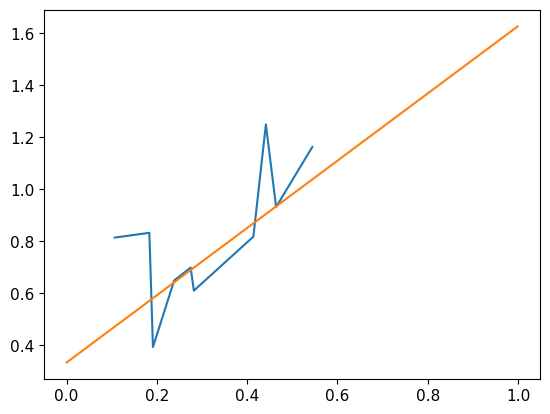

In [194]:

plt.plot(abs_results['x'], abs_results['R0'])
Fmis = 0.2
sigma = 0.1


xs = np.linspace(0,1,1000)
plt.plot(xs,sigma**2+(Fmis+(1-Fmis)*xs)/(1-Fmis-(1-Fmis)*xs)*(1-xs)*SNR_base)


#plt.plot(abs_results['x'],sigma**2+(Fmis+(1-Fmis)*abs_results['x'])/(1-Fmis-(1-Fmis)*abs_results['x'])*abs_results['SNR'])

In [193]:
from scipy.optimize import curve_fit

def fit_function(x, Fmis, sigma):
    return sigma**2 + (Fmis+(1-Fmis)*x)/(1-Fmis-(1-Fmis)*x)*(1-x)*SNR_base

curve_fit(fit_function ,abs_results['x'], abs_results['R0'], sigma = abs_results['sR0'], p0 = [0.1,0.])

(array([0.11851665, 0.41005148]),
 array([[ 1.12093190e+11, -2.27503790e+11],
        [-2.27503790e+11,  4.61740579e+11]]))

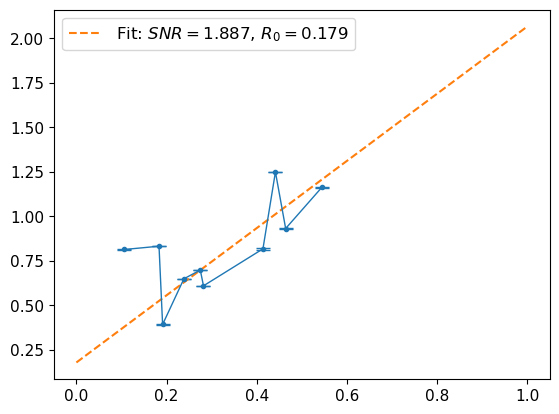

In [206]:
par, cov = np.polyfit(x = abs_results['x'], y = abs_results['R0'], w = 1./abs_results['sR0'], deg = 1, cov = True)
SNR_from_mis , R0_from_mis = par 
plt.errorbar(x = abs_results['x'], y = abs_results['R0'], yerr = abs_results['sR0'],marker = "o", capsize  =  5, markersize = 3, linewidth = 1, elinewidth=1)

xs = np.linspace(0,1)
plt.plot(xs, xs*SNR_from_mis+R0_from_mis,linestyle = '--', label = f'Fit: $SNR = {round(SNR_from_mis, 3)}$, $R_0= {round(R0_from_mis,3)}$')

plt.legend()

### prova con siti specifici

In [209]:
sorted_sites = np.argsort(np.mean(g_matrix, axis = 1))[::-1] 
sorted_sites[-1]

np.int64(135)

In [210]:
np.sum(g_matrix[sorted_sites[-1], :]**2)

np.float64(23.915937267505573)

In [211]:
norm

np.float64(715.9832084710067)

In [212]:
np.sum(g_matrix**2)

np.float64(715.9832084710067)

In [178]:
g_matrix.shape

(178, 20)

In [ ]:
n_trials = 5

p_values = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]#[0.1,0.2,0.3,0.4,0.5]

split_fractions = [0.1,0.2,0.3]
mu_grid = 10**(np.array([-4,-2.5,-1.5,-1]))
r_values = np.zeros(len(split_fractions))
x_values = np.zeros(len(p_values))
risk_values = np.zeros((len(p_values), len(split_fractions), len(mu_grid), n_trials))
avg_risk = np.zeros((len(p_values), len(split_fractions), len(mu_grid)))
std_risk = np.zeros((len(p_values), len(split_fractions), len(mu_grid)))

sorted_sites = np.argsort(np.sum(g_matrix**2, axis = 1))[::] 


for id_x, p in enumerate(p_values):

    print(id_x) 

    hidden_fraction = 0
    sites_to_hide = 0
    mask_matrix = np.ones((L,q), dtype = np.int32)
    while hidden_fraction < p: 
        sites_to_hide += 1
        hidden_fraction += np.sum(g_matrix[sorted_sites[-sites_to_hide], :]**2)/norm
        mask_matrix[sorted_sites[-sites_to_hide],:] = 0
   
    L_new = L-sites_to_hide
    mask = mask_matrix.flatten()

    new_norm = np.sum(mask_matrix*g_matrix**2)

    x = (norm-new_norm)/norm

    print(f"New norm: {new_norm}, so I have hidden a fraction x = {x} of the parameter vector by hidind the {sites_to_hide} most important sites")

    x_values[id_x] = x

    for i, test_size in enumerate(split_fractions):

        print(f"\t{i}")
        r_values[i] = q * L_new / len(G_train)

        for j, mu in enumerate(mu_grid):

            for trial in range(n_trials):

                delta_train, delta_test, G_train, G_test = train_test_split(delta, G, test_size=test_size)

                delta_train = mask*delta_train                

                if mu < 5*10**(-8): g_hat, delta_mean, G_mean  = ridge_regression_stable(delta_train, G_train, mu)
                else: g_hat, delta_mean, G_mean  = ridge_regression(delta_train, G_train, mu)
                X_test = delta_test - delta_mean[None,:]
                G_pred = X_test @ g_hat + G_mean
                risk_values[id_x, i,j,trial] = np.mean((G_pred-G_test)**2)
            print(np.mean(risk_values[id_x,i,j,:]))

avg_risk = np.mean(risk_values  , axis = 3)
std_risk = np.std(risk_values, axis = 3)/np.sqrt(n_trials)      

0
New norm: 618.432846859161, so I have hidden a fraction x = 0.1362467170426608 of the parameter vector by hidind the 1 most important sites
	0
0.5865654541200216
0.5340069714968745
1.1929385494495925
1.5366399680672915
	1
0.48311392901231764
0.6104835738588135
1.3487238623676758
1.5172382754604752
	2
0.4899497037495705
0.6342558377763379
1.2722341916640116
1.664369631302582
1
New norm: 532.8249523847289, so I have hidden a fraction x = 0.2558136195364345 of the parameter vector by hidind the 2 most important sites
	0
0.47183394176054116
0.6383437084739222
1.3389688950977585
1.527189319721632
	1
0.4950101815754797
0.6077307696769737
1.3550657011386886
1.5121270346623548
	2


KeyboardInterrupt: 

# All antibodies

In [7]:
exp_data_path = 'exp_data/'
abs = pd.read_csv(exp_data_path+"ab_classification.csv")
abs[abs['condition_subtype'] == 'class 1']

,condition,condition_subtype
0,COV2-2196,class 1
7,COV2-2165,class 1
8,COV2-2832,class 1
14,C105,class 1
20,REGN10933,class 1
22,LY-CoV016,class 1
27,S2E12,class 1
33,S2H14,class 1


In [ ]:
infile = "exp_data/test_risk/S2X16.csv"
# infile = 'exp_data/test_risk/data.csv'
data = pd.read_csv("exp_data/test_risk/S2X16.csv")
data.head(10)

,Ab,q,L,M,r,mu,R,sR,nTest,nTrial
0,S2X16,20.0,178.0,1589.0,2.240403,1.000000e-09,0.443088,0.045117,83.0,30.0
1,S2X16,20.0,178.0,1422.0,2.503516,1.000000e-09,0.375417,0.019235,250.0,30.0
2,S2X16,20.0,178.0,1254.0,2.838915,1.000000e-09,0.415717,0.016608,418.0,30.0
3,S2X16,20.0,178.0,1087.0,3.275069,1.000000e-09,0.425967,0.010249,585.0,30.0
4,S2X16,20.0,178.0,920.0,3.869565,1.000000e-09,0.427460,0.008156,752.0,30.0
5,S2X16,20.0,178.0,753.0,4.727756,1.000000e-09,0.449666,0.009866,919.0,30.0
6,S2X16,20.0,178.0,586.0,6.075085,1.000000e-09,0.505198,0.016130,1086.0,30.0
7,S2X16,20.0,178.0,418.0,8.516746,1.000000e-09,0.551011,0.015983,1254.0,30.0
8,S2X16,20.0,178.0,335.0,10.626866,1.000000e-09,0.654140,0.026388,1337.0,30.0
9,S2X16,20.0,178.0,251.0,14.183267,1.000000e-09,0.738716,0.026886,1421.0,30.0


In [ ]:
outfile = 'exp_data/test_risk/data.csv'

n_trials = 10
q = 20 
L = len(WT_SEQ)

split_fractions = [0.05,0.15,0.25,0.35,0.45,0.55,0.65,0.75,0.8,0.85,0.9,0.95,0.975]
mu_grid = 10**(np.array([-9,-8,-7,-6.5,-6,-5.5,-5,-4.5,-4,-3.5,-3,-2,-1,0]))
r_values = np.zeros(len(split_fractions))


def get_cols_to_remove(L, q, WT):
    cols = set()
    for site in range(L):
        base = site * (q+1)
        cols.add(base + q)       # ultima feature del sito
        #cols.add(base + WT[site])     # feature wild-type del sito
    return sorted(cols)

already_done = data['Ab'].unique()

for id, row in abs.iterrows():

    AB = row['condition']
    if AB in already_done: continue
    
    print(AB)

    try: 
        with open(exp_data_path+"starr_nature/DMS_"+AB+".csv", 'r') as file:
            print("DMS data found")
    except: 
        print("DMS data not found")
        continue         


    with open(exp_data_path+"starr_nature/DMS_"+AB+".csv", 'r') as file:
        line = file.readline().split(sep = ',')
        M = int(line[0])
        N = int(line[1])

        delta = np.zeros((M,N),dtype = np.float32)
        G = np.zeros(M,dtype = np.float64)
        for m in range(M):
            line = file.readline().split(sep = ',')
            delta[m] = [int(line[i]) for i in range(N)]
            G[m] = float(line[-1])
    # remove gap       
    cols_to_remove = get_cols_to_remove(L, q, WT_SEQ)
    cols_to_keep   = [i for i in range(N) if i not in set(cols_to_remove)]
    
    delta_new = delta[:, cols_to_keep]
    delta = delta_new.copy()
    
    risk_values = np.zeros(n_trials)

    for i, test_size in tqdm(enumerate(split_fractions)):

        for j, mu in enumerate(mu_grid):

            for trial in range(n_trials):

                delta_train, delta_test, G_train, G_test = train_test_split(delta, G, test_size=test_size)

                if j == 0 and trial == 0: r_values[i] = q * L / len(G_train)

                if mu < 5*10**(-8): g_hat, delta_mean, G_mean  = ridge_regression_stable(delta_train, G_train, mu)
                else: g_hat, delta_mean, G_mean  = ridge_regression(delta_train, G_train, mu)
                X_test = delta_test - delta_mean[None,:]
                G_pred = X_test @ g_hat + G_mean
                risk_values[trial] = np.mean((G_pred-G_test)**2)

            avg_risk = np.mean(risk_values)
            std_risk = np.std(risk_values)/np.sqrt(n_trials)   
        
            data = pd.concat([data, pd.DataFrame({'Ab': [AB],'q':[q], 'L': [L], 'M': [len(G_train)], 'r': [q * L / len(G_train)], 'mu': [mu], 'R': [avg_risk], 'sR': [std_risk],'nTest': [len(G_test)],'nTrial': [n_trials]})])
  
data.to_csv(outfile, index = False)    


COV2-2130
DMS data found


13it [17:49, 82.29s/it]


COV2-2955
DMS data not found
CR3022
DMS data found


13it [17:44, 81.88s/it]


COV2-2677
DMS data found


...

REGN10987
DMS data found


13it [17:43, 81.80s/it]


S309
DMS data found


1it [02:59, 179.07s/it]


KeyboardInterrupt: 